In [1]:
import pandas as pd
import seaborn as sns

In [2]:
data = pd.read_csv('spam_ham_dataset.csv')

1) EDA

In [13]:
print(data.iloc[6]['text'])

Subject: spring savings certificate - take 30 % off
save 30 % when you use our customer appreciation spring savings
certificate at foot locker , lady foot locker , kids foot locker and at
our online stores !
welcome to our customer appreciation spring savings certificate !
use the special certificate below and receive 30 % off your purchases either in our stores or online . hurry ! this 4 - day sale begins thursday , march 22 and ends sunday , march 25 .
share the savings today and e - mail this offer to your friends . many items already are reduced and the 30 % discount is taken off the lowest sale price .
click below to print your customer appreciation spring savings certificate . you must present this coupon at any foot locker , lady foot locker or kids foot locker store in the u . s . foot locker canada is not participating in this program .
ready , set , save !
our spring savings discount will automatically appear when you use the links below or type camlem 21 into the promotion c

In [ ]:
# Idea: split text to subject and message.
# use bag of words: count occurance of each word...
# map them to one-hot encoder...

In [16]:
mapping = {'ham': 0, 'spam':1}
data['label'] = data['label'].map(mapping)

In [19]:
data['label'].value_counts()

,count
label,
0,3672
1,1499


<Axes: xlabel='label'>

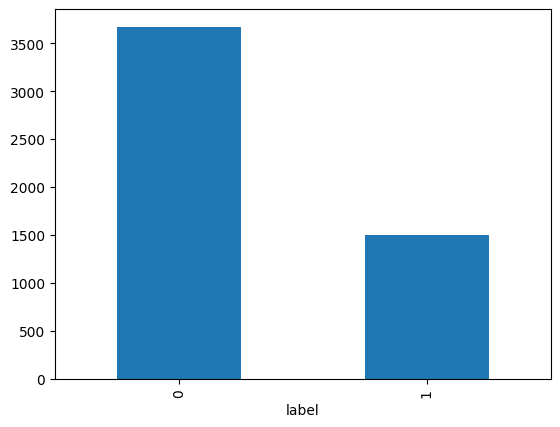

In [25]:
data['label'].value_counts().plot(kind='bar')

In [33]:
data['subject'] = data['text'].str.extract(r'Subject:\s*(.*?)\r\n')


In [35]:
# 2. Remove the "Subject: ... \r\n" prefix from the text to get the body
data['text_body'] = data['text'].str.replace(r'^Subject:.*?\r\n', '', regex=True)

# 3. Clean all remaining '\r\n' occurrences from the body (replace with space)
data['text_body'] = data['text_body'].str.replace(r'\r\n', ' ', regex=True)

In [37]:
data['text_body'] = data['text_body'].str.replace(r':', '', regex=True)

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [49]:
tfidf_text_body = TfidfVectorizer(stop_words='english',max_features=1000)
text_body_tfi = tfidf_text_body.fit_transform(data['text_body'])

tfidf_subject = TfidfVectorizer(stop_words='english',max_features=1000)
subject_tfi = tfidf_subject.fit_transform(data['subject'])


In [50]:
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X = hstack([text_body_tfi, subject_tfi])

y = data['label']

In [51]:
X.shape


(5171, 2000)

Random Forest

In [62]:
# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [63]:
# Initialize the model
# n_estimators=100 means we are using 100 individual decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [64]:
# Make predictions
y_pred = rf_model.predict(X_test)

# Print the results
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 97.49%

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       735
           1       0.94      0.98      0.96       300

    accuracy                           0.97      1035
   macro avg       0.96      0.98      0.97      1035
weighted avg       0.98      0.97      0.98      1035



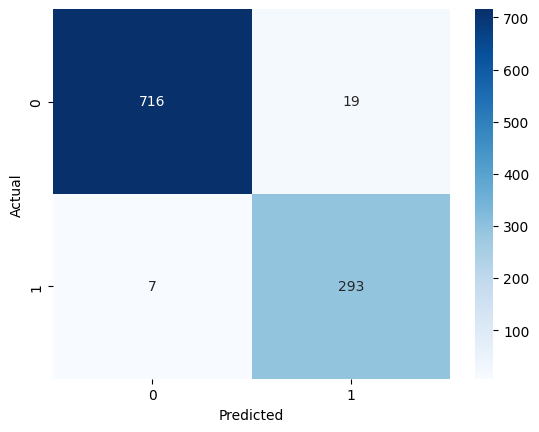

In [65]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
'''
Improve: Other models, finetuning n_estimators, the amount of words for TfidfVectorizer...

'''